# Building Docker with Github Actions

In this lesson, we will look at how to build, tag and publish Docker images with Github Actions and Github Packages. Github Packages supports a docker image registry so we can host within the same repository. For this you will need only a browser and a Github account.

# Setup

Create a new repository by clicking the `+` in top right and selecting "New Repository". Name it `cspark-docker-gha`, tick the option to create a README and make it private. 

Now open the editor by pressing `.`. You may perform edits and commits using local VS Code. No plugins are needed.

Once the IDE is ready, create a new branch called `docker-workflow`. 

Copy the contents of the downloaded `data` directory (drag & drop) and commit the change.

## Create a Github Workflow

Create the directory sturcture `.github/workflows/` and add a file called `docker.yaml` with the following skeleton:

```yaml
name: Docker Build

on: [push, workflow_dispatch]

jobs:
  DockerBuildPublish:
    runs-on: ubuntu-latest
    steps:
      - name: Checkout
        uses: actions/checkout@v4
```

At a highlevel, we will define one job `DockerBuildPublish` that will perform multiple steps to build, tag and publish the image. We will use the files from the downloaded data directory. You may use the files as provided for with the modifications from previous lesson. It should not matter.

## Docker Build

While it is possible to install and run docker CLI within the Github runners, we will use the more convenient composite action (predefined) [`docker/build-push-action`](https://github.com/marketplace/actions/build-and-push-docker-images).

The `docker/setup-buildx-action@v3` action installs and configures a `buildx` client to support building multi-architecture images. This is an optional step but often added in commercial environment where the image may need to be built for Intel/AMD (x64/amd64) and ARM processors. We will skip this for the lesson as it is not required.

Add the action `docker/build-push-action` with the following config:


```yaml
- name: Build
  uses: docker/build-push-action@v6
  with:
    push: false
    tags: pythonapp:latest
```

Commit and push the changes. Monitor the workflow execution.

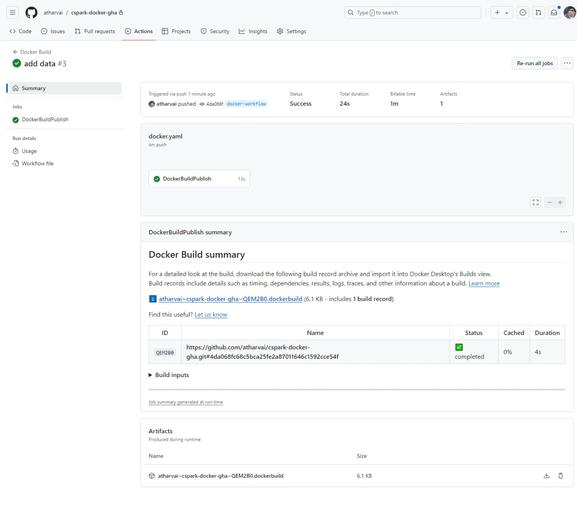

Github Action publishes a friendly summary of the docker build on the Summary page. The logs are still available and show the same logs as local build.

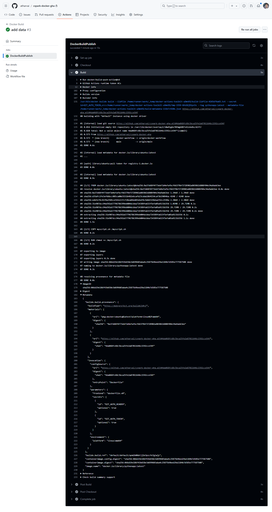

You may notice that we did not specify which Dockerfile to use. As per convention, the default file name used is`Dockerfile`. So it built the image with the simple bash script. To specify a specific file we add the `file: python-webapp.Dockerfile` to the inputs:

```yaml
- name: Build
  uses: docker/build-push-action@v6
  with:
    file: python-webapp.Dockerfile
    push: false
    tags: pythonapp:latest
```

Monitoring the workflow execution and log, this should be building the correct python webapp image. So far it has tagged it as `pythonapp:latest` but not yet published to Github Packages.

## Publish to Github Packages

By default, the action references DockerHub as the registry to push to. Thus the tags printed in the logs use docker.io as the registry address.

To publish to Github Packages, several steps are involved. Firstly we need to tag the image with the correct registry address. To do this we use the `docker/metadata-action` to fetch the registry details for the current Github Repository. Note that Github Packages can be published to the repository level or to the user account level for private accounts or the organisation level for enterprise accounts. Since we are using private accounts, we will publish to repository level. Add the following steps replacing the docker build step:


```yaml
- name: Extract metadata (tags, labels) for Docker
  id: meta
  uses: docker/metadata-action@v5
  with:
    images: ${{ env.REGISTRY }}/${{ env.IMAGE_NAME }}
- name: Build
  uses: docker/build-push-action@v6
  with:
    file: python-webapp.Dockerfile
    push: false
    tags: ${{ steps.meta.outputs.tags }}
    labels: ${{ steps.meta.outputs.labels }}

```

Github Action provided environment variables are used to construct the image tag. Add these environment variables to the workflow before the `jobs` section:

```yaml
env:
  REGISTRY: ghcr.io
  IMAGE_NAME: ${{ github.repository }}/pythonapp
```

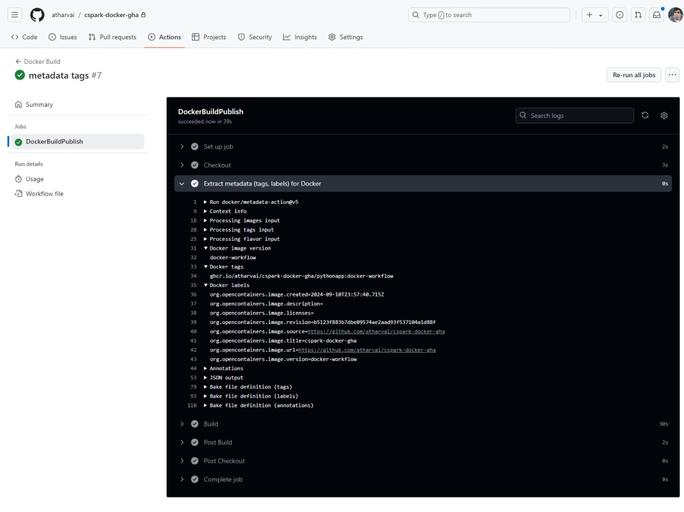

In the logs for the metadata action, you can see that the tag added is `ghcr.io/atharvai/cspark-docker-gha/pythonapp:docker-workflow`. 

- `ghcr.io` is the registry address for Github Packages Docker registry. 
- `atharvai/cspark-docker-gha/pythonapp` is the image name that is constructed from the repository owner, name and the custom image name.
- `docker-workflow` is the image version since that is the branch from which the workflow is executed. This can be modified in the metadata action by setting the following tag value: `type=semver,pattern={{version}},value=v1.0.0`.

Next, the workflow needs to login to Github Packages Docker Registry before pushing the image. Login is another step and action we need to add `docker/login-action`. Add the following step _before_ the metadata action.

```yaml
- name: Log in to the Container registry
  uses: docker/login-action@v3
  with:
    registry: ${{ env.REGISTRY }}
    username: ${{ github.actor }}
    password: ${{ secrets.GITHUB_TOKEN }}
```

Here the registry is specified as `ghcr.io` from the earlier defined environment variable. This overrides the Docker Hub registry. The username is fixed for github actions and is referenced using the `github` context. The `GITHUB_TOKEN` is also a managed token (provided by Github Actions) within the `secrets` context.

Grant permissions for Github ACtions to write to packages by adding this object to the job:

```yaml
permissions:
  contents: read
  packages: write
```

Finally set `push: true` within the `Build` step. Comit and push your changes and monitor the workflow execution.

The final workflow should look like the `data/docker-gha.yaml`

The results should show the successful execution and metadata with the tag for the image:

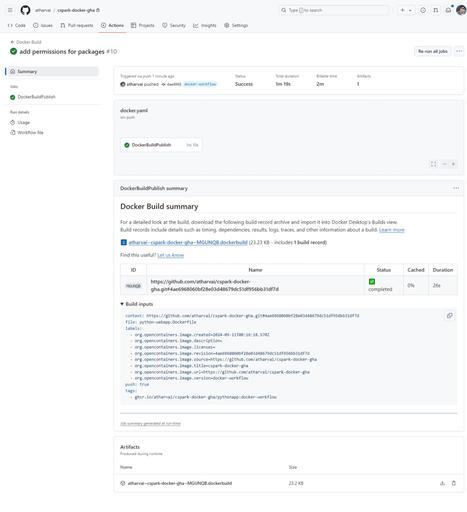


### Verify

In your browser, navigate back to the repository page. In the bottom right section, you will now see `Packages` listed with the docker image name.

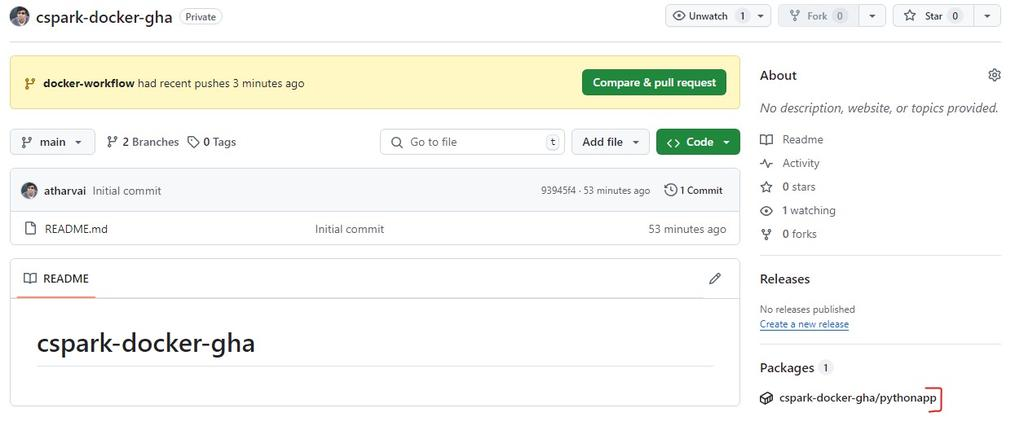

Clicking on the "Packages" heading, show the list of all packages within your user account. This is important to note that the registry is per account or organisation. the naming convention of the repository name prefix on the image links it to the specific repository. You can always view this at `https://github.com/<user>?tab=packages` (substitute your github username).

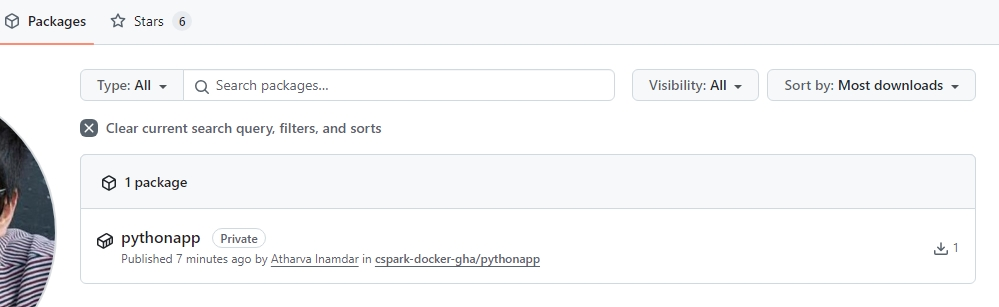

CLicking on the image name takes you to the details of that package. This lists the full image name and version along with the owner and Readme. 

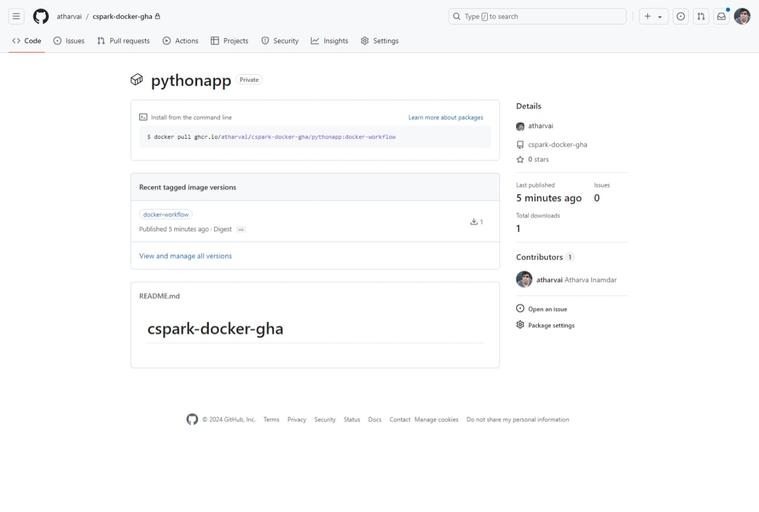

Now let's verify this locally on your machine. 

First, ensure you have a Github Personal Access Token (classic). You can use an existing one or create a new one ensuring it has the `read:packages` permissions enabled.

<details>
<summary>Create new Github Token if needed</summary>

1. Navigate to your settings
1. go to "Developer settings"
1. Go to "Personal Access Tokens" -> "Tokens (classic)"
1. From top right "Generate new token" -> "Generate new token (classic)"
1. Select `read:packages` and generate the token. Keep this token value secure as it cannot be retrieved again. You can always delete and create a new one anytime.

</details>

Open a terminal and first let's login to Github Packages registry.

```bash
export CR_PAT=YOUR_TOKEN
echo $CR_PAT | docker login ghcr.io -u USERNAME --password-stdin
```

This will save your token as an environment variable and use it for logging into `ghcr.io` registry with docker CLI. If you receive any errors, ensure you have the correct token value and permisisons set. 

From your Github Package details page copy the `docker pull` command and execute it. Once downloaded you can verify it using  `docker image ls` command.

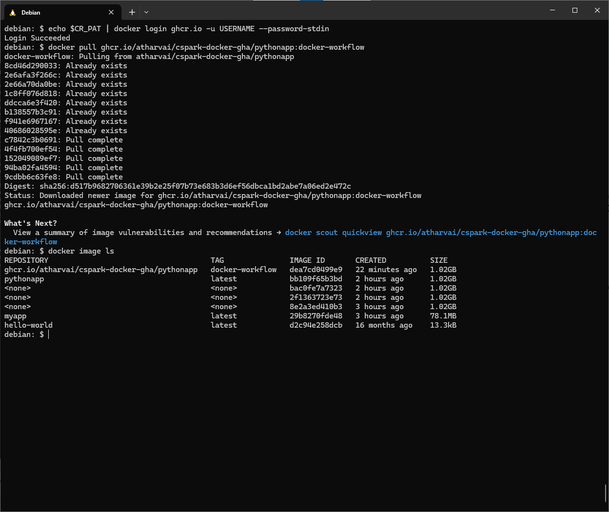

Finally run the container and validate it works as expected:

```bash
docker run --rm -p 5000:5000 ghcr.io/<user>/cspark-docker-gha/pythonapp:docker-workflow
```

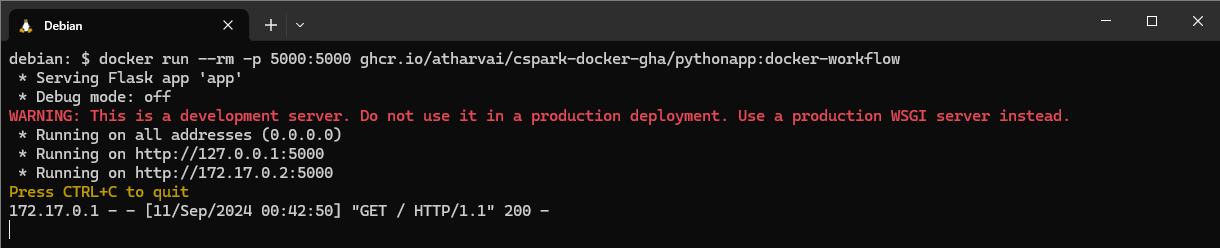
